# Spotify Playlist Explorer

Phase 1 demo: authenticate, pick a playlist (or your Liked Songs), run six analyzers (genres, tags, release year, top artists, duration, timeline) with coordinated colorblind palette and inline coverage annotations, render plots, and optionally export to parquet.

Set `LASTFM_API_KEY` in `.env` to populate the Tag and Genre panels (see the README's "Genres come from Last.fm" bullet under *How that shaped the code*). Without it the two panels are skipped at runtime.

Setup: load credentials from `.env`, set the seaborn theme, and build a
cached `SpotifyClient`. Both caches are anchored to the repo root regardless
of where the notebook is launched from: API responses at `.cache/api/`
(7-day TTL, 365 days for artists) and the OAuth token at
`.cache/spotify_token`. Repeated notebook runs don't re-hit the API.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from spotify_project.analyzer import (
    Analyzer,
    ArtistAnalyzer,
    DurationAnalyzer,
    GenreAnalyzer,
    PlaylistAnalyzer,
    TagAnalyzer,
    TimelineAnalyzer,
    YearAnalyzer,
)
from spotify_project.cache import FileCache
from spotify_project.client import SpotifyClient
from spotify_project.lastfm_client import LastFmClient
from spotify_project.logging_setup import configure_logging

load_dotenv()

APP_LOG_LEVEL = os.getenv("APP_LOG_LEVEL", "INFO")
THIRD_PARTY_LOG_LEVEL = os.getenv("THIRD_PARTY_LOG_LEVEL", "WARNING")
configure_logging(APP_LOG_LEVEL, THIRD_PARTY_LOG_LEVEL)

sns.set_theme(style="whitegrid")
cache = FileCache()
lastfm = LastFmClient.from_env(cache=cache)  # None when LASTFM_API_KEY is unset
client = SpotifyClient.from_env(cache=cache, genre_enricher=lastfm)

## 1. Confirm authentication

In [2]:
user = client.fetch_current_user()
truncated_name = user.display_name[0] + "***" if user.display_name else "Unknown"
print(f"Hello, {truncated_name}")

Hello, B***


## 2. List your playlists

Spotify renamed `tracks` → `items` in their Feb 2026 migration. The `items` field is only present on playlists you own or collaborate on; for followed playlists, `tracks` reads as 0.

In [3]:
import pandas as pd

playlists = client.fetch_user_playlists()
summary = pd.DataFrame(
    [
        {
            "id": p.id,
            "name": p.name,
            "tracks": p.track_count,
            "owner": "self" if p.owner_name == user.display_name else "other",
        }
        for p in playlists
    ]
)
summary.head(20)

,id,name,tracks,owner
0,7CmreRETnY6t2MdHrIiaIA,Top 100 Doo Wop Hits 1953-1964,99,other
1,36qmhWCGOAJt6pRScmHcyb,GTA 6 Soundtrack | 2026 GTA VI 🔥🎮,70,other
2,3ebHKSjHujS4Tyt2KKP97R,Retrowave Synthwave,75,other
3,0O3NMz7IEQJCLtO6tXLaq1,Surf Rock Classics,96,other
4,2ZHmECo8IsjfyWDKo0XwfC,Special Groove,37,other
5,5sDWiz1XZevt4T2qOOir50,Liens hochzeit,4,self
6,3v8PWRLiPHGPY0oHgkoZvV,Ben Böhmer [Not Live],20,self
7,5HMBUSi7dMH6N4l0ME6rzE,Chris Tmas,13,self
8,1oMfydMymnL1wQBxiZStDj,Loopthat,1,self
9,0x3U0VtCmPBEImdkpk177b,Rave In Your Grave,142,other


## 3. Pick a playlist and fetch it

Replace `PLAYLIST_ID` with one of the IDs from the table above, or keep `"__liked__"` to analyze your saved tracks.

In [ ]:
PLAYLIST_ID = "__liked__"  # a playlist ID from the table above, or "__liked__" for your saved tracks
playlist = client.fetch_liked_songs() if PLAYLIST_ID == "__liked__" else client.fetch_playlist(PLAYLIST_ID)  # pyright: ignore[reportUnnecessaryComparison]
print(f"{playlist.name}: {len(playlist.tracks)} tracks")

## 4. Build the PlaylistAnalyzer with all six analyzers

Tweak knobs here:
- `YearAnalyzer(bucket_size=10)` for decade buckets — set to `1` for per-year bars.
- `ArtistAnalyzer(primary_only=True)` to ignore collaborators.
- `TimelineAnalyzer(freq='Y')` for yearly buckets instead of monthly.

Each analyzer reports a small summary DataFrame. Numbers come from the
flattened track DataFrame produced by `PlaylistAnalyzer.from_playlist`.
Coverage attached to each summary surfaces in the chart titles below.

In [5]:
analyzers: list[Analyzer] = [
    GenreAnalyzer(top_n=15),
    TagAnalyzer(top_n=15),
    YearAnalyzer(bucket_size=10),
    ArtistAnalyzer(top_n=15, primary_only=False),
    DurationAnalyzer(bins=20),
    TimelineAnalyzer(freq="M"),
]
analyzer = PlaylistAnalyzer.from_playlist(playlist, analyzers=analyzers)
results = analyzer.run_all()
for title, df in results.items():
    print(title)
    print(df.head(), end="\n\n")

Top Genres
         genre  count
0         rock   1510
1          pop   1452
2   electronic    856
3        indie    808
4  alternative    808

Top Tags
          tag  count
0    american   1637
1        rock   1510
2         pop   1452
3  electronic    856
4       indie    808

Release Year Distribution
   year  count
0  1940      1
1  1950     65
2  1960    199
3  1970    281
4  1980    261

Top Artists
                artist_id         artist_name  track_count  total_minutes
0  3WrFJ7ztbogyGnTHbHJFl2         The Beatles           60     177.841700
1  4tZwfgrHOc3mvqYlEYSvVi           Daft Punk           55     225.150267
2  75fIuwXxhZ1atNzWLMrgF0         Tyler Bates           43      87.500217
3  1Mxqyy3pSjf8kZZL4QVxS0       Frank Sinatra           43     134.793300
4  1cHFz6lrt7KAsBV8j2Ny1g  The Blues Brothers           39     133.855583

Track Duration Distribution
    bin_low  bin_high  count  minutes_in_bin
0  0.000000  0.621855      9        3.026650
1  0.621855  1.243710     37

## 5. Render plots

All six panels stack vertically, each in a distinct colorblind-safe color. `GenreAnalyzer` shows a small grey band at the bottom whenever some tracks have no genre data.

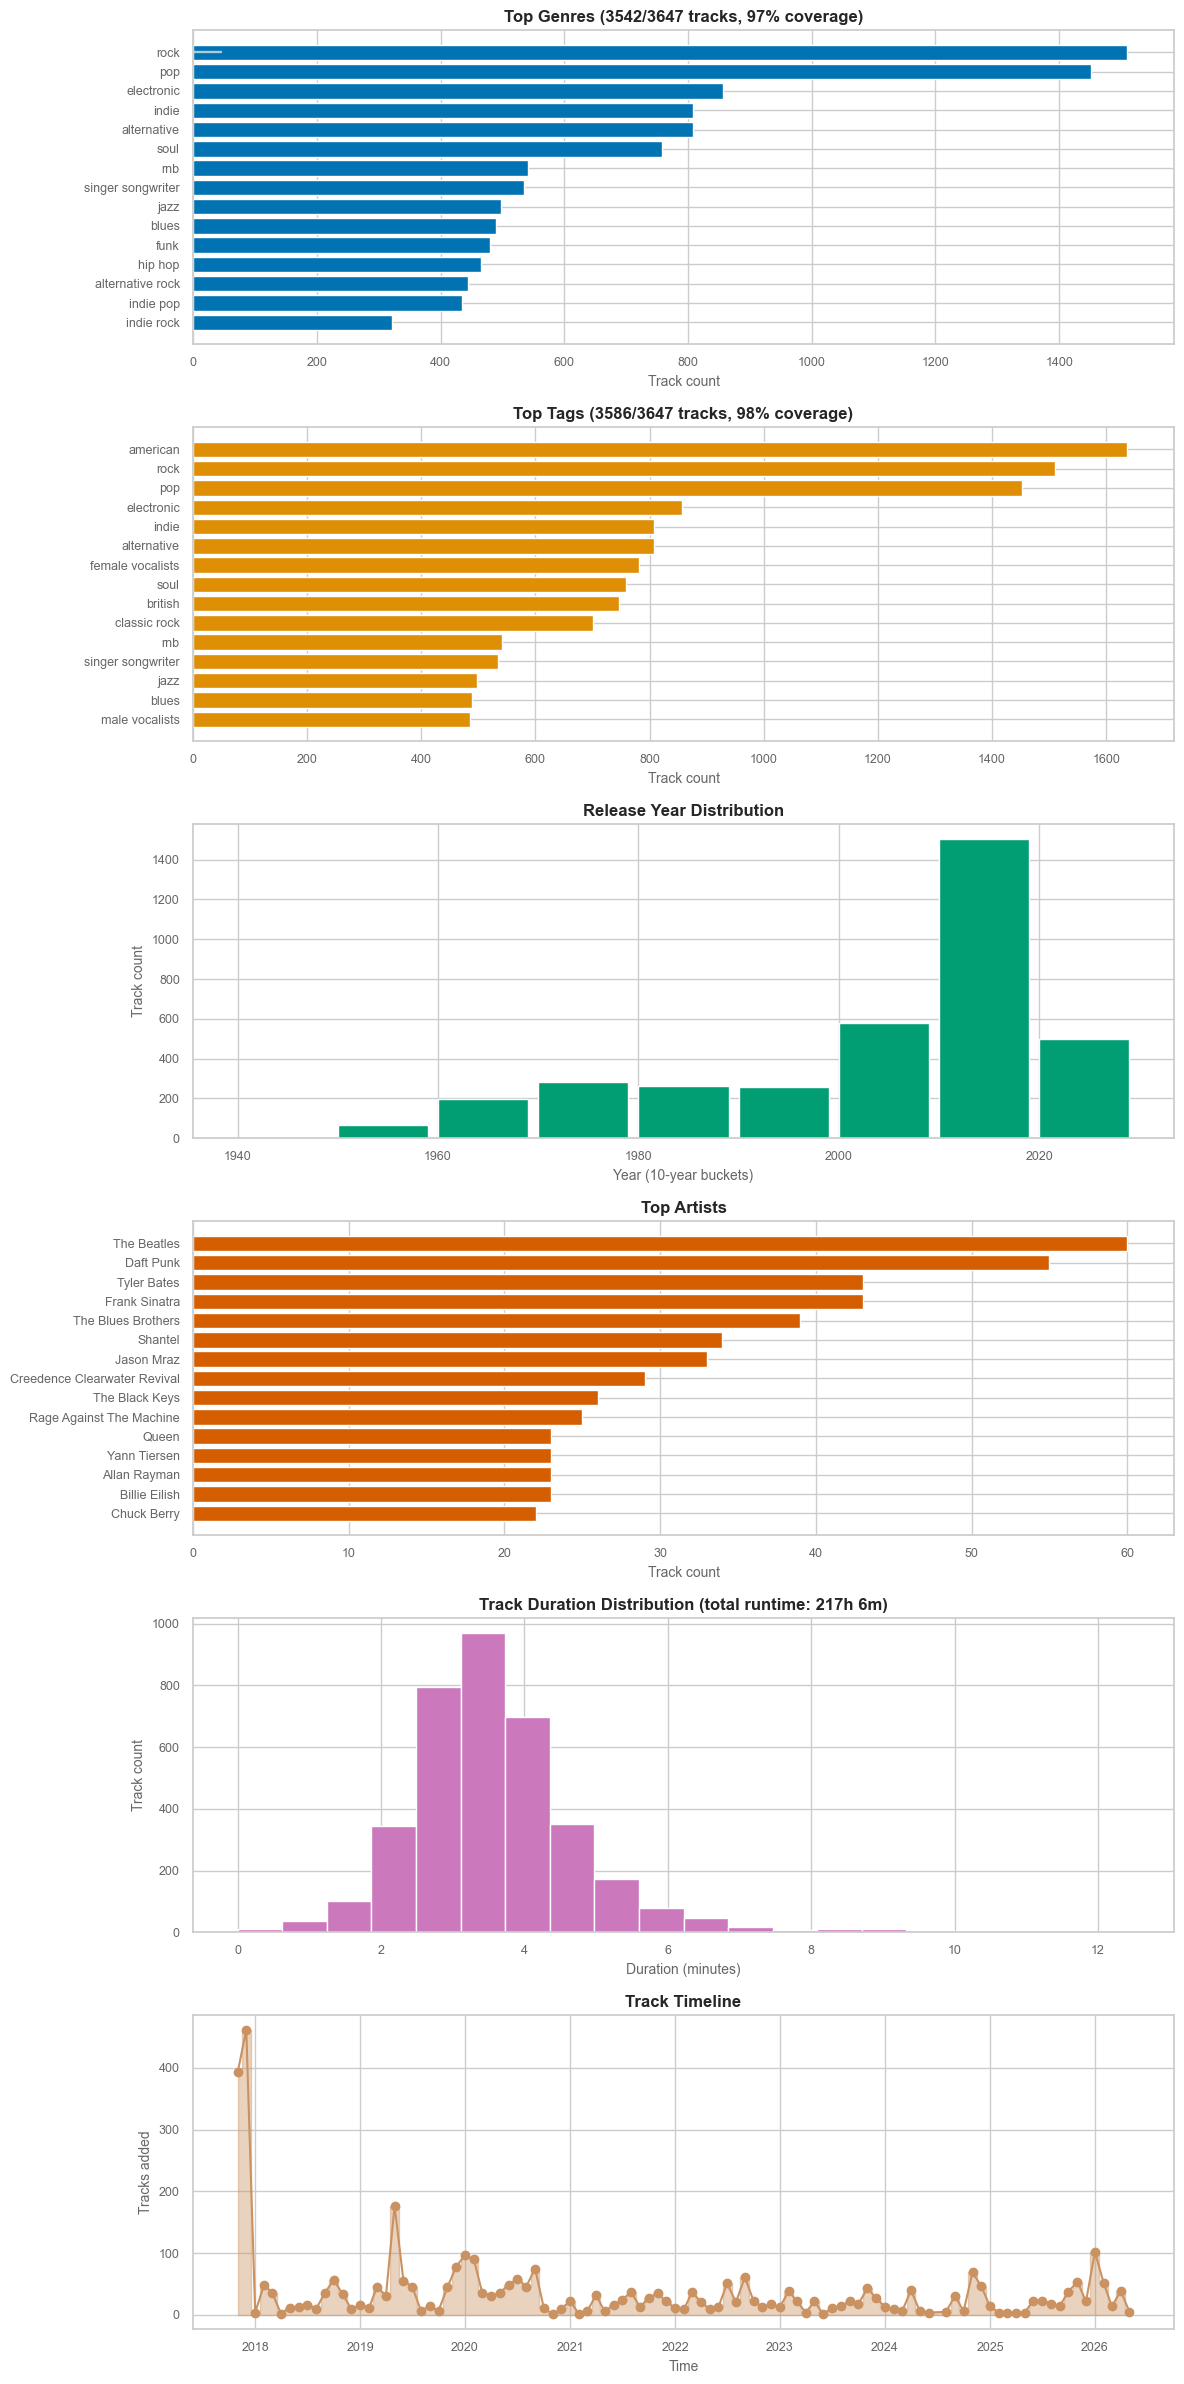

In [6]:
fig = plt.figure(figsize=(12, 24))  # pyright: ignore[reportUnknownMemberType]
analyzer.plot_all(fig)
plt.show()  # pyright: ignore[reportUnknownMemberType]

## 6. (Optional) Export the flattened track DataFrame to parquet

Useful for offline analysis in another tool, or for archiving the snapshot
you analyzed today. The exported parquet preserves the full flattened track
DataFrame (track id/name, primary artist, all artists, album, release date,
duration in minutes, added_at, genres).

In [7]:
EXPORT = False  # set True to write the file
if EXPORT:
    out = Path("exports") / f"{playlist.id}.parquet"
    out.parent.mkdir(parents=True, exist_ok=True)
    analyzer.to_parquet(out)
    print(f"wrote {out}")